In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

print("PyTorch:", torch.__version__)

PyTorch: 2.14.0+cpu


In [9]:
FEATURES = [
    "Time", "Amount", "Amount_log",
    "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9",
    "V10", "V11", "V12", "V13", "V14", "V15", "V16", "V17",
    "V18", "V19", "V20", "V21", "V22", "V23", "V24", "V25",
    "V26", "V27", "V28",
    "Hour_cos", "Hour_sin"
]

TARGET = "Class"

print("Number of features:", len(FEATURES))

Number of features: 33


In [1]:
import pandas as pd
import os

DATA_PATH = "../data/raw/creditcard.csv"

print("File exists:", os.path.exists(DATA_PATH))

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

C:\Users\ahmed\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


File exists: True
Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# 70% Train / 30% temporary
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split the remaining 30% into 15% Validation / 15% Test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)
print("Test:", X_test_raw.shape)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train: (199364, 30)
Validation: (42721, 30)
Test: (42722, 30)

Train class distribution:
Class
0    199020
1       344
Name: count, dtype: int64

Validation class distribution:
Class
0    42647
1       74
Name: count, dtype: int64

Test class distribution:
Class
0    42648
1       74
Name: count, dtype: int64


In [29]:
import sys

# Allow Python to find files inside src/
sys.path.insert(0, "../src")

from preprocessing import FraudPreprocessor

preprocessor = FraudPreprocessor.load(
    "../artifacts/preprocessing_pipeline.pkl"
)

print("Preprocessor loaded successfully!")
print("Feature order:")
print(preprocessor.feature_order)


Preprocessor loaded successfully!
Feature order:
['Time', 'Amount', 'Amount_log', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour_cos', 'Hour_sin']


In [4]:
X_train_final = preprocessor.transform(X_train_raw)
X_val_final = preprocessor.transform(X_val_raw)
X_test_final = preprocessor.transform(X_test_raw)

print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

Train: (199364, 33)
Validation: (42721, 33)
Test: (42722, 33)


In [5]:
X_train_normal = X_train_final[y_train.values == 0]

In [6]:
import os

os.makedirs("../data/processed", exist_ok=True)

train_processed = X_train_final.copy()
train_processed["Class"] = y_train.values

val_processed = X_val_final.copy()
val_processed["Class"] = y_val.values

test_processed = X_test_final.copy()
test_processed["Class"] = y_test.values

train_processed.to_csv(
    "../data/processed/train.csv",
    index=False
)

val_processed.to_csv(
    "../data/processed/validation.csv",
    index=False
)

test_processed.to_csv(
    "../data/processed/test.csv",
    index=False
)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!


In [9]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=33):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            
            nn.Linear(16, 8)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.LeakyReLU(),
            
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model = Autoencoder(input_dim=33)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=33, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=32, out_features=33, bias=True)
  )
)


In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)

Device: cpu


In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer: Adam")

Loss: MSELoss()
Optimizer: Adam


In [16]:
import numpy as np

# Convert normal training data and validation data to NumPy
X_train_np = X_train_normal.to_numpy(dtype=np.float32)
X_val_np = X_val_final.to_numpy(dtype=np.float32)

print("X_train_np shape:", X_train_np.shape)
print("X_val_np shape:", X_val_np.shape)

X_train_np shape: (199020, 33)
X_val_np shape: (42721, 33)


In [17]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)

# Create DataLoaders
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 778
Validation batches: 167


In [18]:
EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # -----------------
    # Training
    # -----------------
    model.train()

    train_loss = 0.0

    for (batch,) in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        reconstructed = model(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.size(0)

    train_loss /= len(train_loader.dataset)

    # -----------------
    # Validation
    # -----------------
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for (batch,) in val_loader:

            batch = batch.to(device)

            reconstructed = model(batch)

            loss = criterion(reconstructed, batch)

            val_loss += loss.item() * batch.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/20] Train Loss: 0.549375 Val Loss: 0.374432
Epoch [2/20] Train Loss: 0.317542 Val Loss: 0.296195
Epoch [3/20] Train Loss: 0.274885 Val Loss: 0.264702
Epoch [4/20] Train Loss: 0.250429 Val Loss: 0.248521
Epoch [5/20] Train Loss: 0.233024 Val Loss: 0.341106
Epoch [6/20] Train Loss: 0.225502 Val Loss: 0.231060
Epoch [7/20] Train Loss: 0.217366 Val Loss: 0.220928
Epoch [8/20] Train Loss: 0.213280 Val Loss: 0.219512
Epoch [9/20] Train Loss: 0.206225 Val Loss: 0.219683
Epoch [10/20] Train Loss: 0.202071 Val Loss: 0.232173
Epoch [11/20] Train Loss: 0.196694 Val Loss: 0.207987
Epoch [12/20] Train Loss: 0.194450 Val Loss: 0.205375
Epoch [13/20] Train Loss: 0.190015 Val Loss: 0.204657
Epoch [14/20] Train Loss: 0.188567 Val Loss: 0.198664
Epoch [15/20] Train Loss: 0.184740 Val Loss: 0.200240
Epoch [16/20] Train Loss: 0.183010 Val Loss: 0.194796
Epoch [17/20] Train Loss: 0.179754 Val Loss: 0.198147
Epoch [18/20] Train Loss: 0.177148 Val Loss: 0.192492
Epoch [19/20] Train Loss: 0.176007 Va

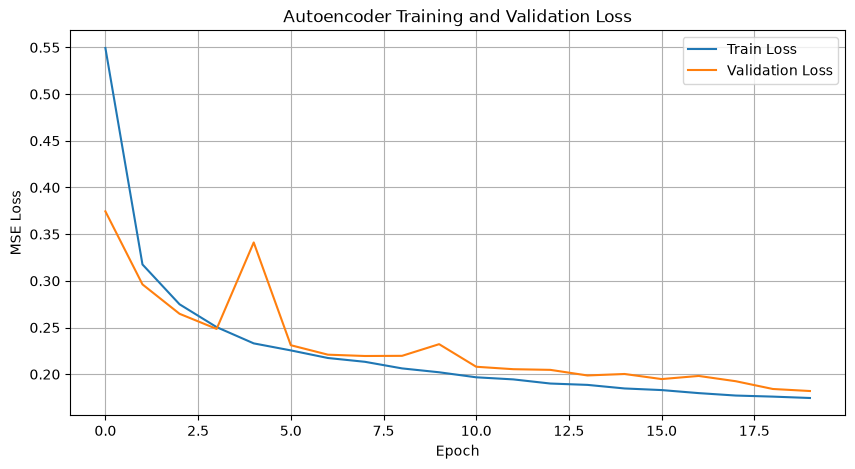

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
def calculate_anomaly_scores(model, data_loader, device):
    model.eval()
    scores = []

    with torch.no_grad():
        for (batch,) in data_loader:
            batch = batch.to(device)

            reconstructed = model(batch)

            # MSE for each transaction
            error = torch.mean((batch - reconstructed) ** 2, dim=1)

            scores.extend(error.cpu().numpy())

    return np.array(scores)


# Calculate anomaly scores for validation data
val_scores = calculate_anomaly_scores(
    model,
    val_loader,
    device
)

print("Number of validation scores:", len(val_scores))
print("Minimum score:", val_scores.min())
print("Maximum score:", val_scores.max())
print("Mean score:", val_scores.mean())

Number of validation scores: 42721
Minimum score: 0.012160572
Maximum score: 53.313843
Mean score: 0.18200316


In [21]:
from sklearn.metrics import f1_score

# Validation labels
y_val_np = y_val.to_numpy()

# Try different threshold values
thresholds = np.percentile(
    val_scores,
    np.linspace(90, 99.9, 100)
)

best_threshold = None
best_f1 = -1

for threshold in thresholds:
    predictions = (val_scores >= threshold).astype(int)

    f1 = f1_score(y_val_np, predictions)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Validation F1:", best_f1)

Best Threshold: 3.7661664581299585
Best Validation F1: 0.6


In [22]:
THRESHOLD = 3.7661664581299585

print("Final Threshold:", THRESHOLD)

Final Threshold: 3.7661664581299585


In [23]:
import os
import torch

os.makedirs("../models", exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dim": 33,
    "threshold": THRESHOLD,
    "feature_order": list(X_train_final.columns),
    "architecture": {
        "encoder": [33, 32, 16, 8],
        "decoder": [8, 16, 32, 33]
    }
}

torch.save(
    checkpoint,
    "../models/autoencoder.pth"
)

print("Autoencoder saved successfully!")

Autoencoder saved successfully!


In [24]:
# Prepare test data
X_test_np = X_test_final.to_numpy(dtype=np.float32)

X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)

test_dataset = TensorDataset(X_test_tensor)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

# Calculate anomaly scores
test_scores = calculate_anomaly_scores(
    model,
    test_loader,
    device
)

print("Number of test scores:", len(test_scores))
print("Minimum score:", test_scores.min())
print("Maximum score:", test_scores.max())
print("Mean score:", test_scores.mean())

Number of test scores: 42722
Minimum score: 0.012608192
Maximum score: 52.900734
Mean score: 0.18002413


In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# True labels
y_test_np = y_test.to_numpy()

# Predictions using validation-based threshold
y_test_pred = (test_scores >= THRESHOLD).astype(int)

# Metrics
accuracy = accuracy_score(y_test_np, y_test_pred)
precision = precision_score(y_test_np, y_test_pred, zero_division=0)
recall = recall_score(y_test_np, y_test_pred, zero_division=0)
f1 = f1_score(y_test_np, y_test_pred, zero_division=0)

print("=== Autoencoder Test Results ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_np,
    y_test_pred,
    target_names=["Normal", "Fraud"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, y_test_pred))

=== Autoencoder Test Results ===
Accuracy : 0.9985
Precision: 0.5775
Recall   : 0.5541
F1 Score : 0.5655

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42648
       Fraud       0.58      0.55      0.57        74

    accuracy                           1.00     42722
   macro avg       0.79      0.78      0.78     42722
weighted avg       1.00      1.00      1.00     42722


Confusion Matrix:
[[42618    30]
 [   33    41]]


In [26]:
import sys
sys.path.insert(0, "../src")

from dl_pipeline import load_autoencoder, calculate_anomaly_score

model_path = "../models/autoencoder.pth"

model, threshold, device = load_autoencoder(model_path)

print("Model loaded successfully!")
print("Threshold:", threshold)
print("Device:", device)

Model loaded successfully!
Threshold: 3.7661664581299585
Device: cpu


In [27]:
# Take one transaction from the test set
sample = X_test_np[0]

# Calculate anomaly score
score = calculate_anomaly_score(
    model,
    sample,
    device
)[0]

# Classification based on threshold
prediction = 1 if score >= threshold else 0

print("Anomaly Score:", score)
print("Threshold:", threshold)
print("Prediction:", "Fraud/Anomaly" if prediction == 1 else "Normal")

Anomaly Score: 0.09802902
Threshold: 3.7661664581299585
Prediction: Normal
